### Objective

Tier 2 (Chronos-2, zero-shot) scored on the **imv_start** windows from Notebook 11.

Same model and same procedure as Notebook 13. The only change is the input: windows are now placed forward from ventilation start (deployment-realistic), and Tier 1 predictions come from Notebook 12. Results are saved with an `_imvstart` suffix so they stay separate from the original Tier 2 results.

Chronos-2 is never trained, so it has no random seed to vary. The determinism check near the end confirms that; the run-to-run spread lives in the trained tiers (Notebooks 12 and 14).

### 01. Setup and configuration

* Install the Chronos-2 package and import the libraries needed.
* Fix the random seed and select the device.
* Reuse the same paths, context length and horizons as Notebook 12.

In [1]:
!pip install "chronos-forecasting>=2.0" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 3.7 MB/s eta 0:00:00


AI-assisted: Claude Opus 4.8 assisted with project setup and configuration.

In [2]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from chronos import Chronos2Pipeline
from google.colab import drive

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ---- Project setup ----
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/ventilator_weaning')

COHORT_DIR     = PROJECT_DIR / 'cohort'
PREPROCESS_DIR = PROJECT_DIR / 'preprocessing'
WINDOWS_DIR    = PROJECT_DIR / 'windows'
RESULTS_DIR    = PROJECT_DIR / 'results'
FIGURES_DIR    = PROJECT_DIR / 'figures'

# Safe to run again, does nothing if the folders already exist
for d in [COHORT_DIR, PREPROCESS_DIR, WINDOWS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Files this notebook reads (from notebooks 07 and 08)
GRID_PATH          = WINDOWS_DIR / "windows_tier12_grid_imvstart.npz"
METADATA_PATH      = WINDOWS_DIR / "windows_metadata_imvstart.json"
TIER1_RESULTS_PATH = RESULTS_DIR / "tier1_itransformer_results_imvstart.csv"
TIER1_PRED_PATH    = RESULTS_DIR / "tier1_test_predictions_imvstart.npz"

# Files this notebook writes
TIER2_RESULTS_PATH = RESULTS_DIR / "tier2_chronos2_results_imvstart.csv"
COMPARISON_PATH    = RESULTS_DIR / "tier1_vs_tier2_comparison_imvstart.csv"
TIER2_PRED_PATH    = RESULTS_DIR / "tier2_test_predictions_imvstart.npz"
TIER2_CONFIG_PATH  = RESULTS_DIR / "tier2_run_config_imvstart.json"

# Stop early if an input file is missing
for p in [GRID_PATH, METADATA_PATH, TIER1_RESULTS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Cannot find {p}. Run notebooks 07 and 08 first.")

print("Project folder:", PROJECT_DIR)
print("Input files found.")

# Forecast settings (must match Notebook 12)
CONTEXT_HOURS = 48
HORIZONS = [1, 4, 8]
N_HORIZONS = len(HORIZONS)

# Chronos-2 predicts every hour, so we ask for 8 and keep hours 1, 4 and 8
MAX_HORIZON = max(HORIZONS)
HORIZON_IDX = [h - 1 for h in HORIZONS]

MODEL_NAME = "amazon/chronos-2"
CHUNK_SIZE = 200

print("Configuration loaded")
print(f"Context: {CONTEXT_HOURS} hours")
print(f"Horizons: {HORIZONS}")

Device: cuda
Mounted at /content/drive
Project folder: /content/drive/MyDrive/ventilator_weaning
Input files found.
Configuration loaded
Context: 48 hours
Horizons: [1, 4, 8]


**Interpretation**

The settings copy Notebook 12 exactly. Chronos-2 forecasts every hour, so we ask for 8 hours and then keep only hours 1, 4 and 8 to match Tier 1.

### 02. Loading the windowed data and the saved split

* Load the same arrays and metadata used in Notebook 12.
* Rebuild the train, validation and test masks from the saved split.
* Confirm no patient appears in more than one split.

In [3]:
# Load the metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

# Load the arrays
grid_data = np.load(GRID_PATH, allow_pickle=True)

context = grid_data["X_context"]
context_mask = grid_data["X_context_mask"]
targets = grid_data["y_target"]
target_mask = grid_data["y_target_mask"]

window_ids = grid_data["window_ids"]
visit_ids = grid_data["visit_ids"]
split_labels = grid_data["split"]

# Split masks
train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("Data split:")
for name, mask in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    n_patients = len(np.unique(visit_ids[mask]))
    n_windows = int(mask.sum())
    print(f"{name:6s}: {n_patients:5d} patients | {n_windows:5d} windows")

# Check the patient split
train_patients = set(visit_ids[train_mask])
val_patients = set(visit_ids[val_mask])
test_patients = set(visit_ids[test_mask])

assert len(train_patients & val_patients) == 0, "Train/Val overlap."
assert len(train_patients & test_patients) == 0, "Train/Test overlap."
assert len(val_patients & test_patients) == 0, "Val/Test overlap."

print("\nSplit checks passed.")

Data split:
Train :  1338 patients |  9079 windows
Val   :   287 patients |  1979 windows
Test  :   287 patients |  1959 windows

Split checks passed.


**Interpretation**

The same patient-level split from Notebook 07 is loaded, so Tier 2 is scored on exactly the same held-out patients as Tier 1. The checks confirm no patient crosses between splits.

### 03. Converting back to native clinical units

* Recover the feature names and scaler statistics from the metadata.
* Un-scale the context and targets back into real clinical units.
* Chronos-2 does its own internal scaling, so it should be given real values.

In [4]:
# Feature names in array column order
feat = metadata["features"]
if isinstance(feat[0], dict):
    feature_names = [f.get("name") or f.get("feature") for f in feat]
else:
    feature_names = list(feat)

N_VARIATES = context.shape[2]

scaler_mean = np.array([metadata["scaler_stats"][f]["mean"] for f in feature_names])
scaler_std = np.array([metadata["scaler_stats"][f]["std"] for f in feature_names])

assert len(feature_names) == N_VARIATES, "Feature name / column count mismatch."

# Un-scale into native units
context_native = context * scaler_std + scaler_mean
targets_native = targets * scaler_std + scaler_mean

print("Feature order:")
print(feature_names)
print(f"\nContext shape: {context_native.shape}")
print(f"Target shape:  {targets_native.shape}")

Feature order:
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Context shape: (13017, 48, 13)
Target shape:  (13017, 3, 13)


**Interpretation**

The arrays are back in real clinical units such as bpm and mmHg. This matters because Chronos-2 normalises each series itself, and because MAE and RMSE are reported in clinical units.

### 04. Persistence baseline

* Build the same carry-forward baseline used in Notebook 12.
* Take the last genuinely observed value in the context and repeat it.
* Build it for both the validation and test sets.

In [5]:
def build_persistence(ctx_native, ctx_mask, fallback):
    n = ctx_native.shape[0]
    out = np.zeros((n, N_HORIZONS, N_VARIATES))

    for i in range(n):
        for v in range(N_VARIATES):
            observed = np.where(ctx_mask[i, :, v] == 1)[0]
            if len(observed) > 0:
                last_val = ctx_native[i, observed[-1], v]
            else:
                last_val = fallback[v]
            out[i, :, v] = last_val

    return out


val_persist = build_persistence(
    context_native[val_mask], context_mask[val_mask], scaler_mean
)
test_persist = build_persistence(
    context_native[test_mask], context_mask[test_mask], scaler_mean
)

print(f"Validation baseline shape: {val_persist.shape}")
print(f"Test baseline shape:       {test_persist.shape}")

Validation baseline shape: (1979, 3, 13)
Test baseline shape:       (1959, 3, 13)


**Interpretation**

The baseline is built the same way as in Notebook 12, so the MASE denominator is identical for both tiers. This is what makes the two MASE numbers directly comparable.

### 05. Metric functions

* Define masked MAE and RMSE that only score genuinely observed cells.
* Define a helper that returns overall MAE and MASE for a set of predictions.
* Use the same formulas as Notebook 12.

In [6]:
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


def overall_scores(pred, true, mask, persist):
    mae = masked_mae_native(pred, true, mask)
    persist_mae = masked_mae_native(persist, true, mask)
    return mae, mae / (persist_mae + 1e-8)


print("Metric functions ready.")

Metric functions ready.


**Interpretation**

Only cells where a real measurement exists are scored. Filled values are never counted, so the metrics reflect genuine observations.

### 06. Putting the windows into the Chronos-2 format

* Chronos-2 needs a long table with an item id, a timestamp and the target columns.
* Each window becomes one item, so the five origins of a patient stay separate.
* The is_observed mask is added as extra columns, which Chronos-2 treats as past covariates.

In [7]:
BASE_TIME = pd.Timestamp("2020-01-01")
MASK_COLS = [f"{f}_obs" for f in feature_names]


def build_long_df(ctx_native, ctx_mask, context_len, use_mask):
    n = ctx_native.shape[0]

    # Keep only the most recent hours
    ctx = ctx_native[:, -context_len:, :]
    msk = ctx_mask[:, -context_len:, :]

    # Zero padded ids so sorting keeps the original order
    ids = np.repeat([f"w{j:06d}" for j in range(n)], context_len)
    stamps = np.tile(
        pd.date_range(BASE_TIME, periods=context_len, freq="h"), n
    )

    data = {"item_id": ids, "timestamp": stamps}

    for v, name in enumerate(feature_names):
        data[name] = ctx[:, :, v].reshape(-1).astype("float32")

    if use_mask:
        for v, name in enumerate(MASK_COLS):
            data[name] = msk[:, :, v].reshape(-1).astype("float32")

    return pd.DataFrame(data)


# Quick check on two windows
demo_df = build_long_df(context_native[test_mask][:2], context_mask[test_mask][:2],
                        CONTEXT_HOURS, use_mask=True)

print(f"Rows: {len(demo_df)}  (expected {2 * CONTEXT_HOURS})")
print(f"Columns: {len(demo_df.columns)}")
print(demo_df.head(3))

Rows: 96  (expected 96)
Columns: 28
   item_id           timestamp  diastolic_bp  fio2  heart_rate  lactate  \
0  w000000 2020-01-01 00:00:00          84.0  40.0        93.0      4.6   
1  w000000 2020-01-01 01:00:00          66.0  40.0        92.0      4.6   
2  w000000 2020-01-01 02:00:00          60.0  40.0        84.0      3.0   

   mean_bp     paco2       pao2  peep  ...  lactate_obs  mean_bp_obs  \
0    108.0  5.732860  14.532132   5.0  ...          1.0          1.0   
1     81.0  7.066082   3.599702   5.0  ...          0.0          1.0   
2     72.0  5.466215  15.732033   5.0  ...          1.0          1.0   

   paco2_obs  pao2_obs  peep_obs  ph_obs  respiratory_rate_obs  spo2_obs  \
0        1.0       1.0       1.0     1.0                   1.0       1.0   
1        1.0       1.0       1.0     1.0                   1.0       1.0   
2        1.0       1.0       1.0     0.0                   1.0       1.0   

   systolic_bp_obs  tidal_volume_obs  
0              1.0            

**Interpretation**

Each window becomes 48 rows with 13 target columns and 13 mask columns. Giving every window its own item id stops Chronos-2 joining the five origins of one patient into a single series.

### 07. Loading Chronos-2

* Load the pre-trained weights from Hugging Face.
* No training happens in this notebook, so the model is used exactly as released.
* Print the model size for the write-up.

In [8]:
pipeline = Chronos2Pipeline.from_pretrained(MODEL_NAME, device_map=device)

n_params = sum(p.numel() for p in pipeline.model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Parameters: {n_params:,}")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Model: amazon/chronos-2
Parameters: 119,477,664


**Interpretation**

Chronos-2 has about 120 million parameters, compared with roughly 103 thousand for the Tier 1 iTransformer. The Tier 1 model is far smaller but was trained on this exact task, while Chronos-2 is large but has never seen ICU data.

### 08. Smoke test and reading the output

* Run Chronos-2 on two windows to see the shape of the output.
* Print the output columns so the median forecast can be located reliably.
* This avoids guessing the column names later.

In [9]:
smoke_pred = pipeline.predict_df(
    demo_df,
    prediction_length=MAX_HORIZON,
    quantile_levels=[0.5],
    id_column="item_id",
    timestamp_column="timestamp",
    target=feature_names,
)

# Output is long: one row per window, per hour, per variable
expected = 2 * MAX_HORIZON * N_VARIATES

print(f"Output rows: {len(smoke_pred)}  (expected {expected})")
print("\nOutput columns:")
print(smoke_pred.columns.tolist())
print("\nFirst rows:")
print(smoke_pred.head(3))

Output rows: 208  (expected 208)

Output columns:
['item_id', 'timestamp', 'target_name', 'predictions', '0.5']

First rows:
   item_id           timestamp   target_name  predictions        0.5
0  w000000 2020-01-03 00:00:00  diastolic_bp    54.946079  54.946079
1  w000000 2020-01-03 01:00:00  diastolic_bp    55.117939  55.117939
2  w000000 2020-01-03 02:00:00  diastolic_bp    54.909332  54.909332


**Interpretation**

Chronos-2 returns a long table, not a wide one. Each row is one window, one forecast hour and one variable, named in the target_name column, which is why there are 208 rows for two windows rather than 16. The median forecast sits in the column named 0.5.

### 09. Forecast helper

* Wrap the whole forecast step into one function.
* Work in chunks so memory stays reasonable.
* Return an array shaped like the Tier 1 predictions so the same metric code works.

AI-assisted: Claude Opus 4.8 assisted with Chronos-2 prediction processing.

In [10]:
def extract_predictions(pred_df, n_chunk):
    # Chronos-2 returns long output, so pivot target_name into columns
    value_col = "0.5" if "0.5" in pred_df.columns else "predictions"

    wide = pred_df.pivot(
        index=["item_id", "timestamp"],
        columns="target_name",
        values=value_col,
    )

    # Sorting gives window order then hour order
    wide = wide.sort_index()

    expected = n_chunk * MAX_HORIZON
    assert len(wide) == expected, f"Got {len(wide)} rows, expected {expected}."

    block = wide[feature_names].to_numpy(dtype=np.float32)

    return block.reshape(n_chunk, MAX_HORIZON, N_VARIATES)


def chronos_forecast(ctx_native, ctx_mask, context_len, use_mask):
    n = ctx_native.shape[0]
    out = np.zeros((n, N_HORIZONS, N_VARIATES), dtype=np.float32)

    for start in range(0, n, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, n)
        n_chunk = end - start

        chunk_df = build_long_df(
            ctx_native[start:end], ctx_mask[start:end], context_len, use_mask
        )

        pred_df = pipeline.predict_df(
            chunk_df,
            prediction_length=MAX_HORIZON,
            quantile_levels=[0.5],
            id_column="item_id",
            timestamp_column="timestamp",
            target=feature_names,
        )

        block = extract_predictions(pred_df, n_chunk)

        # Keep only hours 1, 4 and 8
        out[start:end] = block[:, HORIZON_IDX, :]

    return out


print("Forecast helper ready.")

Forecast helper ready.


**Interpretation**

The pivot turns the long output back into an array of shape (windows, 3, 13), exactly matching the Tier 1 prediction array. The assert stops the run early if any window or hour is missing, rather than silently misaligning the results.

### 10. Choosing the settings on the validation set

* Chronos-2 is not trained, so there are no epochs, learning rate or gradients to tune.
* Instead the inference settings are chosen: how much history to show, and whether to pass the mask.
* Only validation data is used here. The test set is not touched.

AI-assisted: hyperparameter sweep over context length and mask settings, generated with Claude Opus 4.8 and verified by the author.

In [11]:
# A subset keeps the sweep fast
SWEEP_N = 300

val_ctx = context_native[val_mask][:SWEEP_N]
val_ctx_mask = context_mask[val_mask][:SWEEP_N]
val_tgt = targets_native[val_mask][:SWEEP_N]
val_tgt_mask = target_mask[val_mask][:SWEEP_N]
val_base = val_persist[:SWEEP_N]

settings = [
    (12, True),
    (24, True),
    (48, True),
    (48, False),
]

sweep_rows = []

for ctx_len, use_mask in settings:
    t0 = time.time()
    preds = chronos_forecast(val_ctx, val_ctx_mask, ctx_len, use_mask)
    mae, mase = overall_scores(preds, val_tgt, val_tgt_mask, val_base)

    sweep_rows.append({
        "context_hours": ctx_len,
        "mask_passed": use_mask,
        "val_MAE": round(mae, 4),
        "val_MASE": round(mase, 4),
        "seconds": round(time.time() - t0, 1),
    })

    print(f"context={ctx_len:2d}h mask={use_mask} -> val MASE {mase:.4f}")

sweep = pd.DataFrame(sweep_rows).sort_values("val_MASE").reset_index(drop=True)

print("\nValidation sweep:")
print(sweep.to_string(index=False))

BEST_CONTEXT = int(sweep.loc[0, "context_hours"])
BEST_USE_MASK = bool(sweep.loc[0, "mask_passed"])

print(f"\nChosen: context={BEST_CONTEXT}h, mask={BEST_USE_MASK}")

context=12h mask=True -> val MASE 0.9203
context=24h mask=True -> val MASE 0.8932
context=48h mask=True -> val MASE 0.8813
context=48h mask=False -> val MASE 0.8834

Validation sweep:
 context_hours  mask_passed  val_MAE  val_MASE  seconds
            48         True  13.8788    0.8813      4.3
            48        False  13.9125    0.8834      2.1
            24         True  14.0673    0.8932      3.0
            12         True  14.4934    0.9203      2.6

Chosen: context=48h, mask=True


**Interpretation**

The best setting is chosen purely on validation MASE.

### 11. Test set forecasts

* Run Chronos-2 once on the test set using the chosen settings.
* Also run it with the Tier 1 context length of 48 hours for a matched comparison.
* The test set is used only here, for final scoring.

In [12]:
test_ctx = context_native[test_mask]
test_ctx_mask = context_mask[test_mask]
test_tgt = targets_native[test_mask]
test_tgt_mask = target_mask[test_mask]

t0 = time.time()
test_preds = chronos_forecast(test_ctx, test_ctx_mask, BEST_CONTEXT, BEST_USE_MASK)
print(f"Forecasting finished in {time.time() - t0:.1f} seconds")

mae_all, mase_all = overall_scores(test_preds, test_tgt, test_tgt_mask, test_persist)
print(f"\nChronos-2 overall test MASE: {mase_all:.4f}")

# Matched setting, same 48 hours of history as Tier 1
if BEST_CONTEXT != CONTEXT_HOURS or not BEST_USE_MASK:
    matched_preds = chronos_forecast(test_ctx, test_ctx_mask, CONTEXT_HOURS, True)
    _, mase_matched = overall_scores(
        matched_preds, test_tgt, test_tgt_mask, test_persist
    )
    print(f"Chronos-2 at matched 48h with mask: MASE {mase_matched:.4f}")
else:
    matched_preds = test_preds
    mase_matched = mase_all
    print("Chosen setting already matches Tier 1.")

Forecasting finished in 26.8 seconds

Chronos-2 overall test MASE: 0.8433
Chosen setting already matches Tier 1.


### Example forecast for one variable, one patient (heart rate)

This is a simple picture of what a single Chronos-2 forecast looks like for the report.
It shows the recent heart-rate history of one test patient, the values that actually
happened next, and the model's forecast at +1, +4 and +8 hours. It is one illustrative
window, not a measure of overall accuracy.

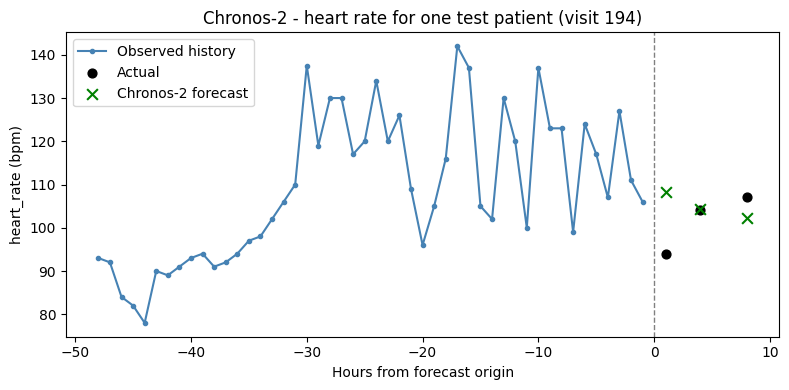

Visit 194, heart rate
  +1h  actual 94.0  forecast 108.3  (off by 14.3 bpm)
  +4h  actual 104.0  forecast 104.4  (off by 0.4 bpm)
  +8h  actual 107.0  forecast 102.3  (off by 4.7 bpm)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick heart rate, and the test window with the most observed future HR points ---
v = feature_names.index("heart_rate")
horizons = HORIZONS                      # [1, 4, 8] hours ahead

hr_future_counts = test_tgt_mask[:, :, v].sum(axis=1)   # observed HR points per window
w = int(np.argmax(hr_future_counts))                 # window with the most HR points

visit = int(visit_ids[test_mask][w])                 # which patient this window is

# --- pull out the numbers for this one window and variable ---
hist_vals = test_ctx[w, :, v]                # recent history (48 hours before origin)
hist_seen = test_ctx_mask[w, :, v] == 1      # which history hours were actually measured
hist_hours = np.arange(-test_ctx.shape[1], 0)          # x-axis: -48 ... -1

actual = test_tgt[w, :, v]                   # what really happened next
actual_seen = test_tgt_mask[w, :, v] == 1    # which future points were measured
forecast = test_preds[w, :, v]                # the model's forecast

# --- plot ---
plt.figure(figsize=(8, 4))
plt.plot(hist_hours[hist_seen], hist_vals[hist_seen],
         "-o", color="steelblue", markersize=3, label="Observed history")
plt.axvline(0, color="grey", linestyle="--", linewidth=1)   # forecast origin
plt.scatter(np.array(horizons)[actual_seen], actual[actual_seen],
            color="black", s=40, label="Actual", zorder=5)
plt.scatter(np.array(horizons)[actual_seen], forecast[actual_seen],
            marker="x", color="green", s=60, label="Chronos-2 forecast", zorder=5)

plt.title(f"Chronos-2 - heart rate for one test patient (visit {visit})")
plt.xlabel("Hours from forecast origin")
plt.ylabel("heart_rate (bpm)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "example_heart_rate_chronos.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Visit {visit}, heart rate")
for h, a, f in zip(horizons, actual, forecast):
    print(f"  +{h}h  actual {a:.1f}  forecast {f:.1f}  (off by {abs(a-f):.1f} bpm)")


**How to read this:** the blue line is the patient's heart rate over the two days before
the forecast is made (the dashed line at 0). The black dots are what heart rate actually did
next, and the green crosses are the forecast. When a green cross sits close to a black dot,
the forecast was close. This is just one window shown as an example; the real accuracy comes
from the pooled scores over all patients above.

**Interpretation**

A MASE below 1.0 means Chronos-2 beats carrying the last value forward, and above 1.0 means it does not. Reporting the matched 48-hour run as well shows the result is not an artefact of giving Chronos-2 a different amount of history.

### 12. Results table

* Report MAE at each horizon, plus overall MAE, RMSE and MASE.
* Report the number of observed cells for each variable.
* Save the table for the dissertation.


AI-assisted: per-variable MAE, RMSE and MASE results table for Chronos-2, generated with Claude Opus 4.8 and verified by the author.

In [14]:
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}

rows = []

for v in range(N_VARIATES):
    name = feature_names[v]
    row = {"variable": name, "unit": UNITS.get(name, "")}

    # MAE at each horizon
    for h_idx, h in enumerate(HORIZONS):
        m = test_tgt_mask[:, h_idx, v]
        row[f"MAE_+{h}h"] = masked_mae_native(
            test_preds[:, h_idx, v], test_tgt[:, h_idx, v], m
        )

    m_all = test_tgt_mask[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )
    row["RMSE_overall"] = masked_rmse_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )

    persist_mae = masked_mae_native(
        test_persist[:, :, v], test_tgt[:, :, v], m_all
    )
    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

tier2_results = pd.DataFrame(rows)

col_order = [
    "variable", "unit",
    "MAE_+1h", "MAE_+4h", "MAE_+8h",
    "MAE_overall", "RMSE_overall", "MASE", "n_observed",
]
tier2_results = tier2_results[col_order].sort_values("MASE").reset_index(drop=True)

display_cols = ["MAE_+1h", "MAE_+4h", "MAE_+8h",
                "MAE_overall", "RMSE_overall", "MASE"]
tier2_results[display_cols] = tier2_results[display_cols].round(3)

print("=== Tier 2 Chronos-2 Results ===\n")
print(tier2_results.to_string(index=False))

tier2_results.to_csv(TIER2_RESULTS_PATH, index=False)
print(f"\nSaved: {TIER2_RESULTS_PATH}")

=== Tier 2 Chronos-2 Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
    tidal_volume          mL   79.453   85.203   93.166       85.966       144.341 0.825        4909
         mean_bp        mmHg    8.854   10.391   10.696        9.983        13.810 0.844        5443
    diastolic_bp        mmHg    6.545    7.678    8.090        7.440        10.542 0.844        5443
     systolic_bp        mmHg   14.168   16.030   16.789       15.667        21.074 0.851        5444
            spo2           %    1.414    1.573    1.719        1.570         2.605 0.887        5261
respiratory_rate breaths/min    3.283    3.880    4.086        3.752         5.736 0.894        4981
      heart_rate         bpm    6.848    8.466    9.409        8.247        11.766 0.934        5482
            fio2    fraction    2.175    2.948    3.720        2.952         7.193 0.941        4928
            pao2         kPa    2.181    2.360    2.550  

**Interpretation**

Variables with MASE below 1.0 are forecast better than persistence, and those above 1.0 are not. Errors should grow from +1h to +8h, and any variable with a small n_observed should be treated with caution.

### 13. Comparing Tier 1 and Tier 2

* Load the Tier 1 results saved in Notebook 12.
* Put the two MASE values side by side for every variable.
* Count how many variables each tier wins.

AI-assisted: variable-wise MASE comparison between Tier 1 iTransformer and Tier 2 Chronos-2, generated with Claude Opus 4.8 and verified by the author.

In [15]:
tier1_results = pd.read_csv(TIER1_RESULTS_PATH)

tier1_mase = dict(zip(tier1_results["variable"], tier1_results["MASE"]))
tier2_mase = dict(zip(tier2_results["variable"], tier2_results["MASE"]))

comparison_rows = []

for v in feature_names:
    t1 = tier1_mase.get(v)
    t2 = tier2_mase.get(v)

    if t1 is None or t2 is None:
        winner = "not available"
        diff = None
    else:
        diff = round(t2 - t1, 3)
        winner = "Tier 1" if t1 < t2 else "Tier 2"

    comparison_rows.append({
        "variable": v,
        "tier1_MASE": round(t1, 3) if t1 is not None else None,
        "tier2_MASE": round(t2, 3) if t2 is not None else None,
        "tier2_minus_tier1": diff,
        "better": winner,
    })

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.sort_values("tier2_minus_tier1").reset_index(drop=True)

print("Tier 1 iTransformer vs Tier 2 Chronos-2\n")
print(comparison.to_string(index=False))

n_t1 = (comparison["better"] == "Tier 1").sum()
n_t2 = (comparison["better"] == "Tier 2").sum()
mean_gap = comparison["tier2_minus_tier1"].mean()

print(f"\nTier 1 better on {n_t1} variables, Tier 2 better on {n_t2}")
print(f"Mean MASE difference (Tier 2 minus Tier 1): {mean_gap:+.3f}")

comparison.to_csv(COMPARISON_PATH, index=False)
print(f"\nSaved: {COMPARISON_PATH}")

Tier 1 iTransformer vs Tier 2 Chronos-2

        variable  tier1_MASE  tier2_MASE  tier2_minus_tier1 better
         lactate       1.188       1.031             -0.157 Tier 2
            peep       1.164       1.056             -0.108 Tier 2
            fio2       0.980       0.941             -0.039 Tier 2
    tidal_volume       0.800       0.825              0.025 Tier 1
      heart_rate       0.905       0.934              0.029 Tier 1
     systolic_bp       0.821       0.851              0.030 Tier 1
    diastolic_bp       0.813       0.844              0.031 Tier 1
            spo2       0.855       0.887              0.032 Tier 1
respiratory_rate       0.862       0.894              0.032 Tier 1
         mean_bp       0.811       0.844              0.033 Tier 1
              ph       0.956       0.997              0.041 Tier 1
           paco2       0.923       0.964              0.041 Tier 1
            pao2       0.884       0.942              0.058 Tier 1

Tier 1 better on 10 

In [16]:
# Tier 1 pooled MASE, computed the SAME way as Tier 2's mase_all.
t1_saved = np.load(TIER1_PRED_PATH)
tier1_preds_native = t1_saved["preds_native"]

mase_all_t1 = (
    masked_mae_native(tier1_preds_native, test_tgt, test_tgt_mask)
    / masked_mae_native(test_persist, test_tgt, test_tgt_mask)
)

print(f"Tier 1 pooled MASE (recomputed): {mase_all_t1:.4f}")

Tier 1 pooled MASE (recomputed): 0.8181


In [17]:
# Per-variable-weighted comparison, so no single variable dominates
mean_tier1 = comparison["tier1_MASE"].mean()
mean_tier2 = comparison["tier2_MASE"].mean()

n_beat_persist_t1 = (comparison["tier1_MASE"] < 1.0).sum()
n_beat_persist_t2 = (comparison["tier2_MASE"] < 1.0).sum()

print("Two ways to aggregate across variables:\n")
print(f"Pooled overall MASE   -> Tier 1: {mase_all_t1:.3f} | Tier 2: {mase_all:.3f}")
print("  (weighted by observed cell count, so tidal_volume dominates)\n")
print(f"Mean per-variable MASE -> Tier 1: {mean_tier1:.3f} | Tier 2: {mean_tier2:.3f}")
print("  (each variable counted equally)\n")
print(f"Variables beating persistence -> Tier 1: {n_beat_persist_t1}/13 | Tier 2: {n_beat_persist_t2}/13")

Two ways to aggregate across variables:

Pooled overall MASE   -> Tier 1: 0.818 | Tier 2: 0.843
  (weighted by observed cell count, so tidal_volume dominates)

Mean per-variable MASE -> Tier 1: 0.920 | Tier 2: 0.924
  (each variable counted equally)

Variables beating persistence -> Tier 1: 11/13 | Tier 2: 11/13


**Interpretation**

Both Tier 1 and Tier 2 outperform the persistence baseline for 11 of the 13 variables, with Tier 1 achieving slightly better overall forecasting accuracy than Tier 2

### 14. Paired significance test

* Both tiers were scored on the same windows, so the errors can be paired.
* Use a Wilcoxon signed-rank test on the per-window absolute errors.
* This says whether any gap is larger than random variation.

In [18]:
from scipy.stats import wilcoxon

# Tier 1 predictions come from the file notebook 12 saved to Drive.
if TIER1_PRED_PATH.exists():
    t1_saved = np.load(TIER1_PRED_PATH)
    tier1_preds = t1_saved["preds_native"]

    # Mean absolute error per window, observed cells only
    obs_per_window = test_tgt_mask.sum(axis=(1, 2))
    keep = obs_per_window > 0

    err1 = (np.abs(tier1_preds - test_tgt) * test_tgt_mask).sum(axis=(1, 2))
    err2 = (np.abs(test_preds - test_tgt) * test_tgt_mask).sum(axis=(1, 2))

    err1 = err1[keep] / obs_per_window[keep]
    err2 = err2[keep] / obs_per_window[keep]

    stat, p_value = wilcoxon(err1, err2)

    print(f"Windows compared: {keep.sum()}")
    print(f"Tier 1 mean window error: {err1.mean():.4f}")
    print(f"Tier 2 mean window error: {err2.mean():.4f}")
    print(f"Wilcoxon p-value: {p_value:.2e}")
else:
    print("Tier 1 test predictions not saved in Notebook 12.")
    print("Re-run the Notebook 12 evaluation cell and save preds_native to:")
    print(TIER1_PRED_PATH)

Windows compared: 1959
Tier 1 mean window error: 12.9355
Tier 2 mean window error: 13.3670
Wilcoxon p-value: 4.13e-06


**Interpretation**

A small p-value means the difference between the two tiers is consistent across windows rather than noise.

### 15. Figures

* Plot MASE by variable for both tiers on the same axes.
* Plot how error grows from +1h to +8h for both tiers.
* Save both figures for the dissertation.

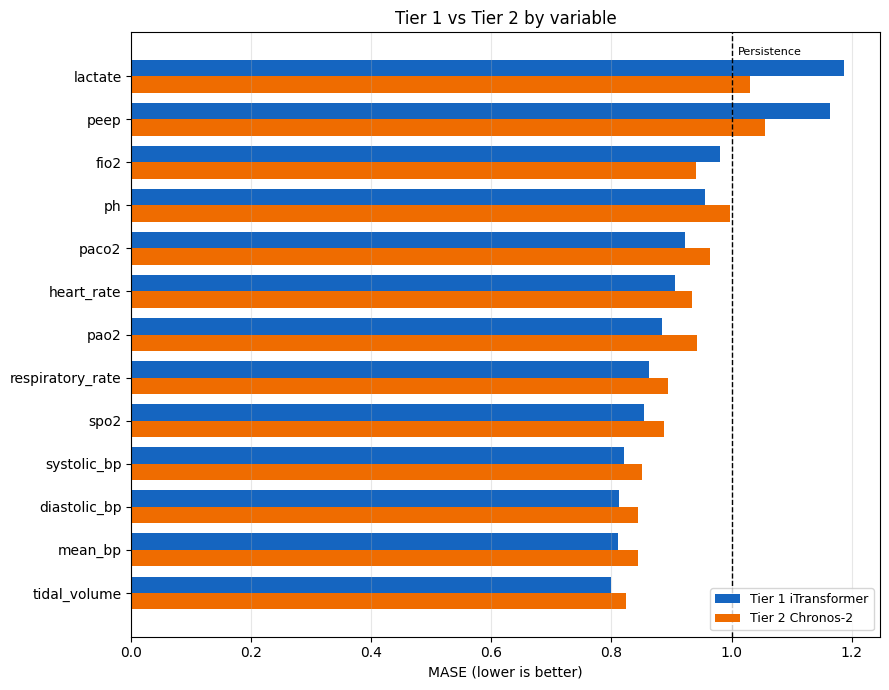

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_vs_tier2_mase_imvstart.png


In [19]:
plot_df = comparison.dropna(subset=["tier1_MASE", "tier2_MASE"]).copy()
plot_df = plot_df.sort_values("tier1_MASE")

y = np.arange(len(plot_df))
height = 0.38

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(y + height / 2, plot_df["tier1_MASE"], height,
        color="#1565c0", label="Tier 1 iTransformer")
ax.barh(y - height / 2, plot_df["tier2_MASE"], height,
        color="#ef6c00", label="Tier 2 Chronos-2")

ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.01, len(plot_df) - 0.5, "Persistence", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("MASE (lower is better)")
ax.set_title("Tier 1 vs Tier 2 by variable")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tier1_vs_tier2_mase_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_vs_tier2_mase_imvstart.png'}")

**Interpretation**

Bars to the left of the dashed line beat persistence. Comparing the pairs shows which variables each approach handles better.

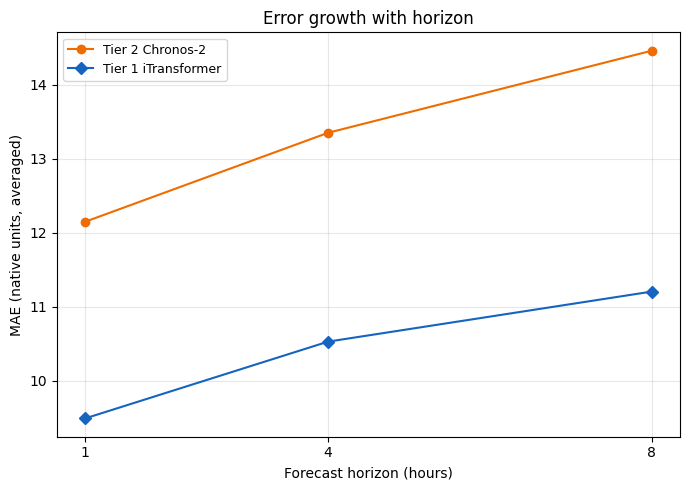

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_vs_tier2_horizon_imvstart.png


In [20]:
t1_h = []
t2_h = []

for h_idx, h in enumerate(HORIZONS):
    m = test_tgt_mask[:, h_idx, :]
    t2_h.append(masked_mae_native(test_preds[:, h_idx, :], test_tgt[:, h_idx, :], m))
    t1_h.append(
        tier1_results[f"MAE_+{h}h"].mean()
        if f"MAE_+{h}h" in tier1_results.columns else np.nan
    )

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(HORIZONS, t2_h, marker="o", color="#ef6c00", label="Tier 2 Chronos-2")
ax.plot(HORIZONS, t1_h, marker="D", color="#1565c0", label="Tier 1 iTransformer")

ax.set_xlabel("Forecast horizon (hours)")
ax.set_ylabel("MAE (native units, averaged)")
ax.set_title("Error growth with horizon")
ax.set_xticks(HORIZONS)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tier1_vs_tier2_horizon_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_vs_tier2_horizon_imvstart.png'}")

**Interpretation**

Both are rising, because forecasting further ahead is harder. A steeper line means that model degrades faster over the eight hours.

### 16. Saving the artifacts

* Save the Tier 2 predictions so later notebooks can reuse them.
* Save to a permanent folder, not the temporary Colab folder.
* Record the chosen settings alongside the predictions.

In [21]:
np.savez_compressed(
    TIER2_PRED_PATH,
    preds_native=test_preds,
    targets_native=test_tgt,
    target_mask=test_tgt_mask,
    persistence=test_persist,
    visit_ids=visit_ids[test_mask],
)

run_config = {
    "model": MODEL_NAME,
    "context_hours": BEST_CONTEXT,
    "mask_passed": BEST_USE_MASK,
    "horizons": HORIZONS,
    "overall_test_MASE": float(mase_all),
    "matched_48h_MASE": float(mase_matched),
    "n_test_windows": int(test_mask.sum()),
    "n_test_patients": int(len(np.unique(visit_ids[test_mask]))),
}

with open(TIER2_CONFIG_PATH, "w") as f:
    json.dump(run_config, f, indent=2)

# Read back to confirm the files saved
check = np.load(TIER2_PRED_PATH)
assert check["preds_native"].shape == test_preds.shape, "Saved predictions do not match."

print("Saved predictions and run config to Drive.")
print(json.dumps(run_config, indent=2))

Saved predictions and run config to Drive.
{
  "model": "amazon/chronos-2",
  "context_hours": 48,
  "mask_passed": true,
  "horizons": [
    1,
    4,
    8
  ],
  "overall_test_MASE": 0.8433177917977399,
  "matched_48h_MASE": 0.8433177917977399,
  "n_test_windows": 1959,
  "n_test_patients": 287
}


**Interpretation**

The predictions are stored on Drive so Tier 3 can be compared without re-running
Chronos-2.

Chronos-2 was tested zero-shot on the same windows and baseline as iTransformer — no training, just picking the best context length on validation. Its main limitations are that it received the filled hourly grid rather than raw irregular data (conservative test), the mask is passed differently to Tier 1, and the validation sweep used only 300 windows. The origin-anchoring limitation from NB07 still applies. Next: Tier 3 GraFITi on raw irregular triplets.